# Qiita記事の分析：企業勢の記事は個人勢のより伸びやすいのか

In [ ]:
%pip install requests

In [1]:
import json

with open("env.json", encoding="utf-8") as f:
    TOKEN = json.load(f)["token"]

## 記事を取得

In [ ]:
import requests
import time

headers = {
    "Authorization": f"Bearer {TOKEN}"
}

url = "https://qiita.com/api/v2/items"

# 2026-06-01から2026-06-08まで(06/08含む)の記事を取得
query = "created:>=2026-06-01 created:<2026-06-09"

all_items = []
page = 1

while True:
    response = requests.get(
        url,
        headers=headers,
        params={
            "query": query,
            "page": page,
            "per_page": 100
        }
    )
    response.raise_for_status()

    items = response.json()

    if not items:
        break

    all_items.extend(items)

    print(f"page={page}, count={len(items)}")

    page += 1

    # レート制限対策
    time.sleep(1)

print(f"取得記事数: {len(all_items)}")

for item in all_items[:5]:
    print(
        item["title"],
        item["likes_count"],
        item["url"]
    )

queryで使えるオプション
https://help.qiita.com/ja/articles/qiita-search-options

In [9]:
# 記事本体を削除して軽量化＋保存
import json

items_without_body = []

for item in all_items:
    item_copy = item.copy()
    item_copy.pop("body", None)
    item_copy.pop("rendered_body", None)
    items_without_body.append(item_copy)

with open("qiita_items.json", "w", encoding="utf-8") as f:
    json.dump(
        items_without_body,
        f,
        ensure_ascii=False,
        indent=2
    )

データ取得日：2026年6月9日11:48ほど

## いいねを分析

データはもうある→qiita_items.json

なので、ここから実行すればOK

In [ ]:
%pip install matplotlib

In [3]:
import json

with open("qiita_items.json", encoding="utf-8") as f:
    all_items = json.load(f)

In [5]:
# いいねが1以上の記事
items_with_likes = [item for item in all_items if item["likes_count"] >= 1]

# 企業勢の記事
company_items = [
    item
    for item in all_items
    if item["organization_url_name"] is not None
]

print("全記事数:", len(all_items))
print("いいねがついている記事数:", len(items_with_likes))
print("企業勢の記事の数:", len(company_items))
print("個人勢の記事の数:", len(all_items) - len(company_items))
print(
    "企業勢の記事の割合:",
    f"{len(company_items) / len(all_items) * 100:.1f}%"
)

全記事数: 3161
いいねがついている記事数: 941
企業勢の記事の数: 446
個人勢の記事の数: 2715
企業勢の記事の割合: 14.1%


### いいねが付いた記事の中で企業勢は何%か？

P(企業勢の記事 | いいねあり)

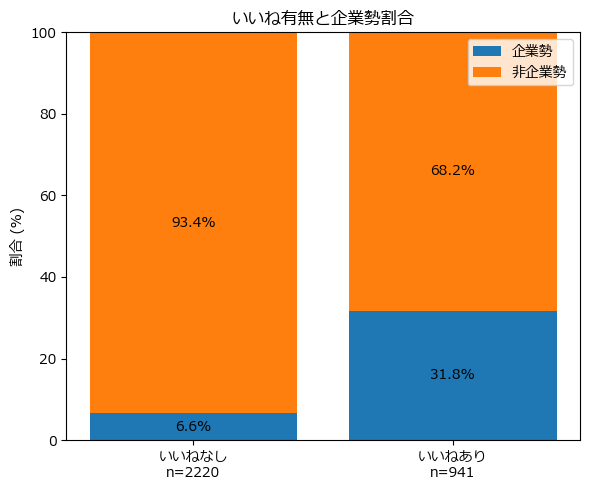

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Meiryo"

# 分類
items_with_likes = [item for item in all_items if item["likes_count"] >= 1]
items_without_likes = [item for item in all_items if item["likes_count"] == 0]

# 件数集計
with_likes_company = sum(
    item["organization_url_name"] is not None
    for item in items_with_likes
)
with_likes_non_company = len(items_with_likes) - with_likes_company

without_likes_company = sum(
    item["organization_url_name"] is not None
    for item in items_without_likes
)
without_likes_non_company = len(items_without_likes) - without_likes_company

# 割合に変換
without_total = len(items_without_likes)
with_total = len(items_with_likes)

company_ratios = [
    without_likes_company / without_total * 100,
    with_likes_company / with_total * 100,
]

non_company_ratios = [
    without_likes_non_company / without_total * 100,
    with_likes_non_company / with_total * 100,
]

# グラフ
labels = [
    f"いいねなし\nn={without_total}",
    f"いいねあり\nn={with_total}"
]

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(labels, company_ratios, label="企業勢")
ax.bar(
    labels,
    non_company_ratios,
    bottom=company_ratios,
    label="非企業勢"
)

ax.set_ylabel("割合 (%)")
ax.set_ylim(0, 100)
ax.set_title("いいね有無と企業勢割合")
ax.legend()

# パーセント表示
for i in range(len(labels)):
    ax.text(
        i,
        company_ratios[i] / 2,
        f"{company_ratios[i]:.1f}%",
        ha="center",
        va="center"
    )

    ax.text(
        i,
        company_ratios[i] + non_company_ratios[i] / 2,
        f"{non_company_ratios[i]:.1f}%",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

### 企業勢の記事はどれくらいの確率でいいねが付くのか

P(いいねあり | 企業勢の記事)

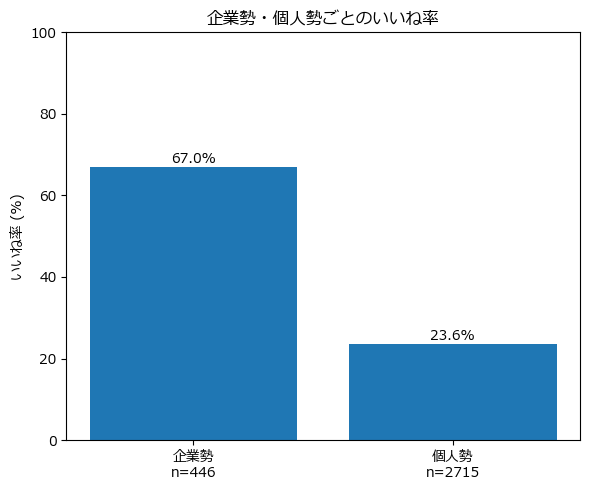

企業勢いいね率: 67.04%
個人勢いいね率: 23.65%


In [6]:
import matplotlib.pyplot as plt

# 分類
company_items = [
    item
    for item in all_items
    if item["organization_url_name"] is not None
]

individual_items = [
    item
    for item in all_items
    if item["organization_url_name"] is None
]

# いいね率計算
company_like_rate = (
    sum(item["likes_count"] >= 1 for item in company_items)
    / len(company_items)
    * 100
)

individual_like_rate = (
    sum(item["likes_count"] >= 1 for item in individual_items)
    / len(individual_items)
    * 100
)

# グラフ
labels = [
    f"企業勢\nn={len(company_items)}",
    f"個人勢\nn={len(individual_items)}",
]

rates = [
    company_like_rate,
    individual_like_rate,
]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(labels, rates)

ax.set_ylim(0, 100)
ax.set_ylabel("いいね率 (%)")
ax.set_title("企業勢・個人勢ごとのいいね率")

# 値表示
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 1,
        f"{rate:.1f}%",
        ha="center",
    )

plt.tight_layout()
plt.show()

print(f"企業勢いいね率: {company_like_rate:.2f}%")
print(f"個人勢いいね率: {individual_like_rate:.2f}%")

### いいね付き記事の中でも、企業勢の方がいいね数が多いのか

In [7]:
import numpy as np

company_liked_items = [
    item for item in company_items
    if item["likes_count"] >= 1
]

non_company_liked_items = [
    item for item in individual_items
    if item["likes_count"] >= 1
]

company_likes = [
    item["likes_count"]
    for item in company_liked_items
]

non_company_likes = [
    item["likes_count"]
    for item in non_company_liked_items
]

print("企業勢")
print("件数:", len(company_likes))
print("平均:", np.mean(company_likes))
print("中央値:", np.median(company_likes))

print()

print("個人勢")
print("件数:", len(non_company_likes))
print("平均:", np.mean(non_company_likes))
print("中央値:", np.median(non_company_likes))

企業勢
件数: 299
平均: 6.414715719063545
中央値: 2.0

個人勢
件数: 642
平均: 2.973520249221184
中央値: 1.0


In [8]:
# 分位点
for name, likes in [
    ("企業勢", company_likes),
    ("個人勢", non_company_likes)
]:
    print(name)

    for p in [50, 75, 90, 95]:
        print(
            f"{p}%:",
            np.percentile(likes, p)
        )

    print()

企業勢
50%: 2.0
75%: 5.0
90%: 10.0
95%: 17.0

個人勢
50%: 1.0
75%: 2.0
90%: 4.0
95%: 8.0



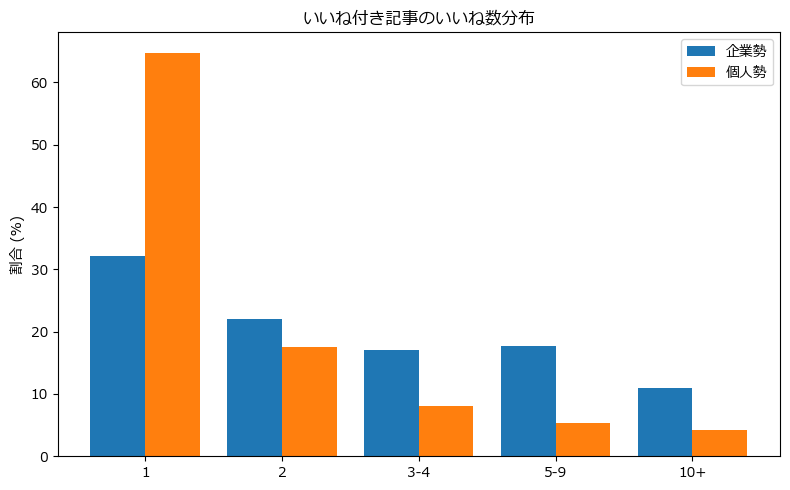

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Meiryo"

# いいね付き記事のみ
company_likes = [
    item["likes_count"]
    for item in company_liked_items
]

non_company_likes = [
    item["likes_count"]
    for item in non_company_liked_items
]

# いいね帯
bins = [
    ("1", 1, 1),
    ("2", 2, 2),
    ("3-4", 3, 4),
    ("5-9", 5, 9),
    ("10+", 10, float("inf")),
]

labels = [label for label, _, _ in bins]

def calc_ratios(likes):
    total = len(likes)

    ratios = []

    for _, low, high in bins:
        count = sum(
            low <= x <= high
            for x in likes
        )

        ratios.append(count / total * 100)

    return ratios

company_ratios = calc_ratios(company_likes)
non_company_ratios = calc_ratios(non_company_likes)

x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width/2,
    company_ratios,
    width,
    label="企業勢"
)

ax.bar(
    x + width/2,
    non_company_ratios,
    width,
    label="個人勢"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("割合 (%)")
ax.set_title("いいね付き記事のいいね数分布")
ax.legend()

plt.tight_layout()
plt.show()
